In [1]:
import os
import json
import pickle

import gower
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
MODEL_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_CSV_PATH = os.path.join(DATA_DIR, "executions_model.csv")
CLUSTERER_PKL = os.path.join(MODEL_DIR, "clusterer.pkl")
KNN_PROXY_PKL = os.path.join(MODEL_DIR, "clusterer_knn_proxy.pkl")
CLUSTER_LABELS_JSON = os.path.join(MODEL_DIR, "cluster_labels.json")
CLUSTERED_CSV = os.path.join(DATA_DIR,  "executions_clustered.csv")


<b>Feature Definition<b>

In [3]:
CLUSTERING_FEATURES = [
    "pattern",
    "severity_encoded",
    "impact_score",
    "complexity_class",
    "score",
    "co_occurring_patterns",
    "total_suggestions",
    "pattern_frequency",
    "line_proximity",
]

In [4]:
CHOSEN_K = 7

<b>Manual Cluster Label Assignment<b>

In [5]:
CLUSTER_LABEL_MAP = {
    0: "hoist_invariant",
    1: "cache_repeated_computation",
    2: "cleanup_dead_unused_code",
    3: "cache_repeated_computation_satellite",
    4: "reduce_nesting",
    5: "memoize_expensive_calls",
    6: "replace_string_concat",
}

<b>Load Data<b>

In [6]:
df = pd.read_csv(MODEL_CSV_PATH)
print(f"Shape: {df.shape}\n")

Shape: (1404, 34)



In [7]:
X = df[CLUSTERING_FEATURES].copy()
for col in ["pattern", "complexity_class", "co_occurring_patterns"]:
    X[col] = X[col].astype(object)

In [8]:
print(f"Clustering feature matrix: {X.shape}")
print(f"Categorical cols: {['pattern','complexity_class','co_occurring_patterns']}")
print(f"Numeric cols: {['severity_encoded','impact_score','score','total_suggestions','pattern_frequency','line_proximity']}\n")

Clustering feature matrix: (1404, 9)
Categorical cols: ['pattern', 'complexity_class', 'co_occurring_patterns']
Numeric cols: ['severity_encoded', 'impact_score', 'score', 'total_suggestions', 'pattern_frequency', 'line_proximity']



<b>Gower Distance Matric<b>

In [9]:
gower_matrix = gower.gower_matrix(X)

In [10]:
# sanity checks - if these fail, something is wrong with the input data

assert gower_matrix.shape == (len(X), len(X)), "Distance matrix shape mismatch"
assert np.isnan(gower_matrix).sum() == 0, "NaN values in distance matrix"
assert gower_matrix.min() >= 0.0, "Negative distances found"
assert gower_matrix.max() <= 1.0 + 1e-9, "Distances exceed 1.0"
 
print(f"Distance matrix shape: {gower_matrix.shape}")
print(f"Distance range: {gower_matrix.min():.4f} - {gower_matrix.max():.4f}\n")

Distance matrix shape: (1404, 1404)
Distance range: 0.0000 - 0.8542



<b>Silhouette Scan<b>

In [11]:
silhouette_scores = {}
for k in range(2, 11):
    model_k = AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage="average",
    )
    labels_k = model_k.fit_predict(gower_matrix)
    score_k = silhouette_score(gower_matrix, labels_k, metric="precomputed")
    silhouette_scores[k] = score_k
    print(f"k={k:2d}  silhouette={score_k:.4f}")
 
print(f"\nChosen k={CHOSEN_K}  score={silhouette_scores[CHOSEN_K]:.4f}")
print(f"Reasoning: k={CHOSEN_K} separates all 6 strategy families with one")
print(f"Satellite cluster; k=6 has one impure cluster (purity=0.59)\n")

k= 2  silhouette=0.2870
k= 3  silhouette=0.4559
k= 4  silhouette=0.4297
k= 5  silhouette=0.4791
k= 6  silhouette=0.6049
k= 7  silhouette=0.6480
k= 8  silhouette=0.6751
k= 9  silhouette=0.6910
k=10  silhouette=0.6989

Chosen k=7  score=0.6480
Reasoning: k=7 separates all 6 strategy families with one
Satellite cluster; k=6 has one impure cluster (purity=0.59)



<b>Fit Final Agglomerative Model<b>

In [12]:
clusterer = AgglomerativeClustering(
    n_clusters=CHOSEN_K,
    metric="precomputed",
    linkage="average",
)
cluster_ids = clusterer.fit_predict(gower_matrix)
print(f"{CHOSEN_K} clusters assigned to {len(cluster_ids)} rows\n")

7 clusters assigned to 1404 rows



<b>Attach Cluster IDs and Labels to Dataframe<b>

In [13]:
df["cluster_id"] = cluster_ids
df["cluster_label"] = df["cluster_id"].map(CLUSTER_LABEL_MAP)
 
# verify the mapping is complete - every cluster_id must have a label
unlabeled = df["cluster_label"].isnull().sum()
assert unlabeled == 0, f"{unlabeled} rows have no cluster label - update CLUSTER_LABEL_MAP"
print("Cluster assignment summary:\n")
for cl_id, cl_label in CLUSTER_LABEL_MAP.items():
    sub = df[df["cluster_id"] == cl_id]
    dom_strat = sub["strategy"].value_counts()
    purity = (sub["strategy"] == dom_strat.idxmax()).mean()
    sil_mean = silhouette_samples(gower_matrix, cluster_ids, metric="precomputed")[df["cluster_id"] == cl_id].mean()
    print(f"Cluster {cl_id} -> '{cl_label}'")
    print(f"rows={len(sub)} purity={purity:.2f} mean_silhouette={sil_mean:.3f}")
    print(f"strategy breakdown: {dom_strat.to_dict()}\n")

Cluster assignment summary:

Cluster 0 -> 'hoist_invariant'
rows=288 purity=0.81 mean_silhouette=0.457
strategy breakdown: {'hoist_invariant': 234, 'reduce_nesting': 18, 'memoize_expensive_calls': 18, 'replace_string_concat': 18}

Cluster 1 -> 'cache_repeated_computation'
rows=432 purity=1.00 mean_silhouette=0.694
strategy breakdown: {'cache_repeated_computation': 432}

Cluster 2 -> 'cleanup_dead_unused_code'
rows=342 purity=1.00 mean_silhouette=0.590
strategy breakdown: {'cleanup_dead_unused_code': 342}

Cluster 3 -> 'cache_repeated_computation_satellite'
rows=18 purity=1.00 mean_silhouette=1.000
strategy breakdown: {'cache_repeated_computation': 18}

Cluster 4 -> 'reduce_nesting'
rows=108 purity=1.00 mean_silhouette=0.869
strategy breakdown: {'reduce_nesting': 108}

Cluster 5 -> 'memoize_expensive_calls'
rows=108 purity=1.00 mean_silhouette=0.851
strategy breakdown: {'memoize_expensive_calls': 108}

Cluster 6 -> 'replace_string_concat'
rows=108 purity=1.00 mean_silhouette=0.672
strat

<b>Build Predict Proxy<b>

In [14]:
NUMERIC_PROXY_FEATURES = [
    "severity_encoded", "impact_score", "score",
    "total_suggestions", "pattern_frequency", "line_proximity",
]
 
X_numeric = df[NUMERIC_PROXY_FEATURES].values
proxy_scaler = StandardScaler()
X_numeric_scaled = proxy_scaler.fit_transform(X_numeric)
 
knn_proxy = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
knn_proxy.fit(X_numeric_scaled, cluster_ids)
proxy_train_acc = knn_proxy.score(X_numeric_scaled, cluster_ids)
print(f"KNN proxy trained on {len(X_numeric)} rows")
print(f"Numeric features used: {NUMERIC_PROXY_FEATURES}")
print(f"Train accuracy (k=1, in-sample): {proxy_train_acc:.4f}\n")

# note: in-sample accuracy is 1.0 by design for k=1 KNN (nearest neighbor is itself)abs
# proxy is used for NEW data in pipeline.py — not for evaluation\

KNN proxy trained on 1404 rows
Numeric features used: ['severity_encoded', 'impact_score', 'score', 'total_suggestions', 'pattern_frequency', 'line_proximity']
Train accuracy (k=1, in-sample): 1.0000



<b>Save Models and Data<b>

In [15]:
with open(CLUSTERER_PKL, "wb") as f:
    pickle.dump({
        "model": clusterer,
        "k": CHOSEN_K,
        "labels": CLUSTER_LABEL_MAP,
        "features": CLUSTERING_FEATURES,
        "gower_matrix": gower_matrix  # save so that classification doesn't recompute
    }, f)
print("Clusterer saved!")

Clusterer saved!


In [16]:
# save KNN proxy and scaler so that pipeline.py can load one artifactabs

with open(KNN_PROXY_PKL, "wb") as f:
    pickle.dump({
        "knn": knn_proxy,
        "scaler": proxy_scaler,
        "features": NUMERIC_PROXY_FEATURES,
        "label_map": CLUSTER_LABEL_MAP
    }, f)
print("KNN proxy saved")

KNN proxy saved


In [17]:
# save the cluster label map as JSON for us

with open(CLUSTER_LABELS_JSON, "w") as f:
    json.dump(CLUSTER_LABEL_MAP, f, indent=2)
print("Cluster label saved!")

Cluster label saved!


In [18]:
# save the full dataset with cluster_id and cluster_label appended

df.to_csv(CLUSTERED_CSV, index=False)
print("Clustered CSV saved!\n")

Clustered CSV saved!



<b>Plots<b>

In [19]:
sns.set_theme(style="whitegrid", context="notebook")

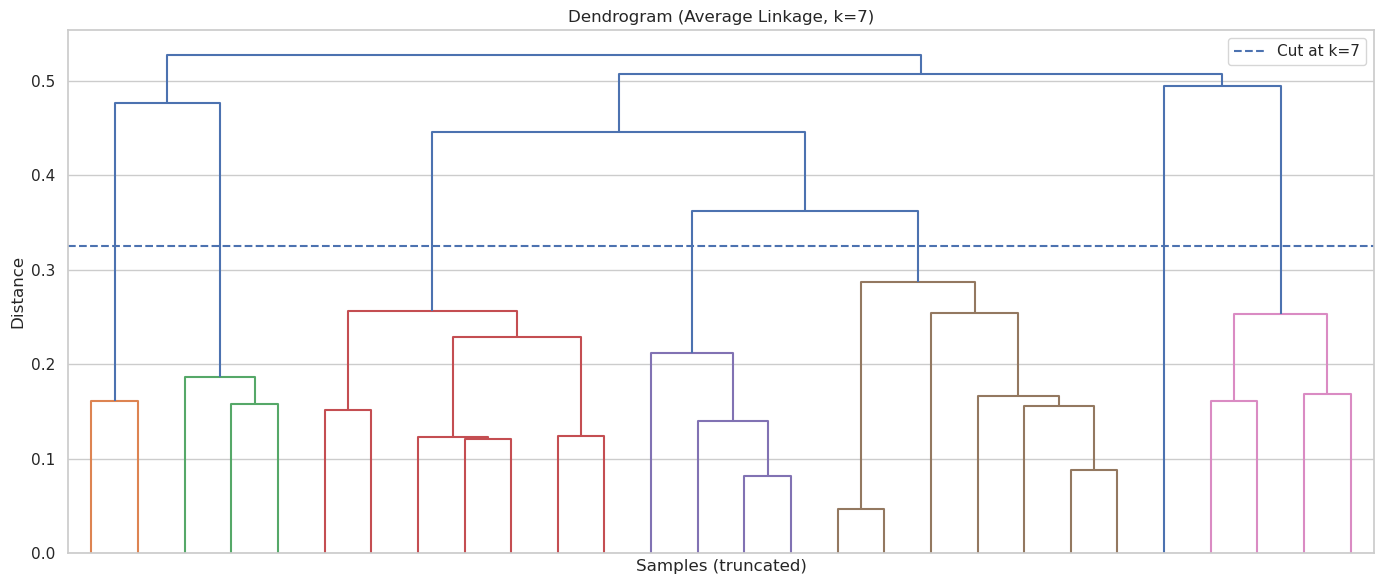

In [20]:
# plot 1: dendrogram

condensed_dm = squareform(gower_matrix, checks=False)
Z = linkage(condensed_dm, method="average")

last_merges = Z[-(CHOSEN_K - 1):, 2]
cut_height  = (last_merges[0] + Z[-(CHOSEN_K), 2]) / 2

plt.figure(figsize=(14, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=CHOSEN_K * 4,
    color_threshold=cut_height,
    no_labels=True,
)

plt.axhline(y=cut_height, linestyle="--", label=f"Cut at k={CHOSEN_K}")

plt.title(f"Dendrogram (Average Linkage, k={CHOSEN_K})")
plt.xlabel("Samples (truncated)")
plt.ylabel("Distance")
plt.legend()

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "cluster_dendrogram.png")
plt.savefig(p, dpi=150)
plt.show()
plt.close()

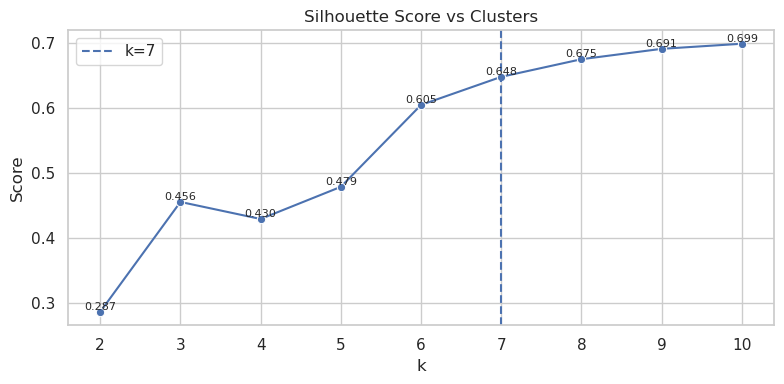

In [21]:
# plot 2: silhouette scores

ks     = list(silhouette_scores.keys())
scores = list(silhouette_scores.values())

plt.figure(figsize=(8, 4))

sns.lineplot(x=ks, y=scores, marker="o")
plt.axvline(CHOSEN_K, linestyle="--", label=f"k={CHOSEN_K}")

for k, s in zip(ks, scores):
    plt.text(k, s, f"{s:.3f}", ha="center", va="bottom", fontsize=8)

plt.title("Silhouette Score vs Clusters")
plt.xlabel("k")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
p = os.path.join(PLOTS_DIR, "cluster_silhouette.png")
plt.savefig(p, dpi=150)
plt.show()
plt.close()

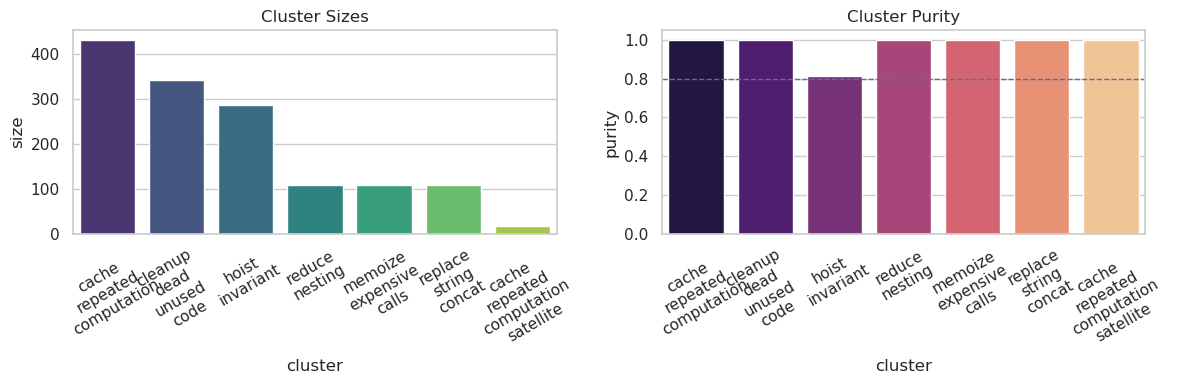

In [28]:
# plot 3: cluster distribution

cs = pd.DataFrame([
    {
        "cluster": cl_label.replace("_", "\n"),
        "size": len(sub := df[df["cluster_id"] == cl_id]),
        "purity": (sub["strategy"] == sub["strategy"].mode()[0]).mean()
    }
    for cl_id, cl_label in CLUSTER_LABEL_MAP.items()
]).sort_values("size", ascending=False)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=cs, x="cluster", y="size", ax=ax[0], palette="viridis")
sns.barplot(data=cs, x="cluster", y="purity", ax=ax[1], palette="magma")

ax[0].set_title("Cluster Sizes")
ax[1].set_title("Cluster Purity")
ax[1].axhline(0.8, ls="--", lw=1)

for a in ax:
    a.tick_params(axis="x", rotation=30)

plt.tight_layout()

p = os.path.join(PLOTS_DIR, "cluster_distribution.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
plt.close()

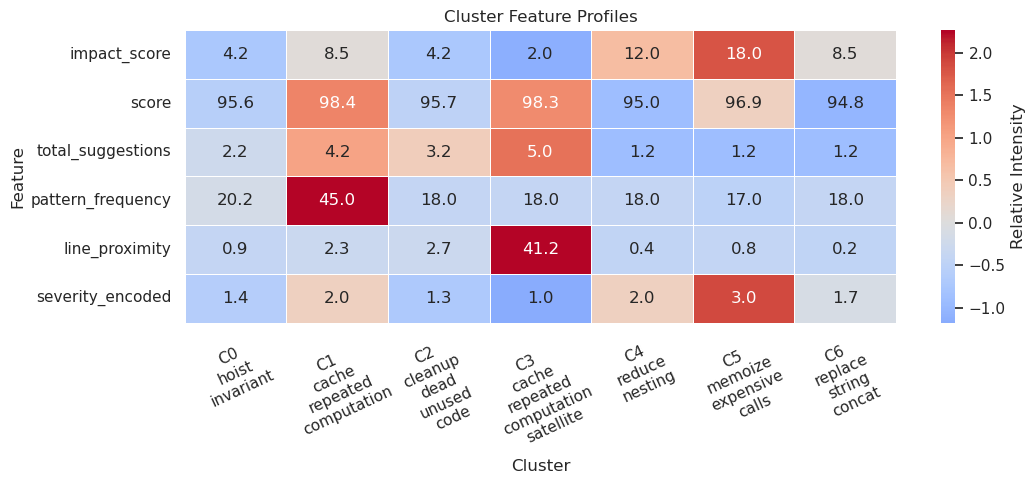

In [27]:
# plot 4: heatmap

numeric_profile_features = [
    "impact_score", "score", "total_suggestions",
    "pattern_frequency", "line_proximity", "severity_encoded",
]

profile_df = pd.DataFrame([
    {
        "cluster": f"C{cl_id}\n{cl_label.replace('_','\n')}",
        **{feat: df[df["cluster_id"] == cl_id][feat].mean()
           for feat in numeric_profile_features}
    }
    for cl_id, cl_label in CLUSTER_LABEL_MAP.items()
]).set_index("cluster")

profile_z = (profile_df - profile_df.mean()) / (profile_df.std() + 1e-9)

plt.figure(figsize=(11, 5))

sns.heatmap(
    profile_z.T,
    annot=profile_df.T.round(1),
    fmt=".1f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Relative Intensity"}
)

plt.title("Cluster Feature Profiles")
plt.xlabel("Cluster")
plt.ylabel("Feature")

plt.xticks(rotation=25)
plt.yticks(rotation=0)

plt.tight_layout()

p = os.path.join(PLOTS_DIR, "cluster_profiles.png")
plt.savefig(p, dpi=150, bbox_inches="tight")
plt.show()
plt.close()